# Geolocation fraud detector
Run the data preprocessing part and the basic analysis.

<class 'pandas.DataFrame'>
RangeIndex: 11799 entries, 0 to 11798
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            11799 non-null  int64  
 1   origin        11799 non-null  str    
 2   ground_truth  11799 non-null  str    
 3   guess         0 non-null      float64
 4   ip_v4         11799 non-null  str    
 5   ip_v6         2437 non-null   str    
 6   latency       11799 non-null  float64
 7   hops          11799 non-null  float64
 8   count         11799 non-null  int64  
 9   date_time     11799 non-null  str    
dtypes: float64(3), int64(2), str(5)
memory usage: 921.9 KB


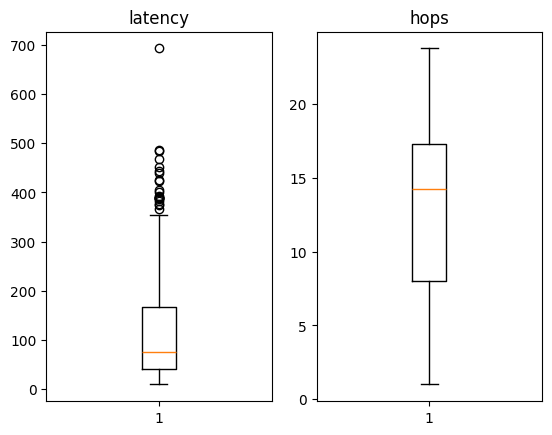

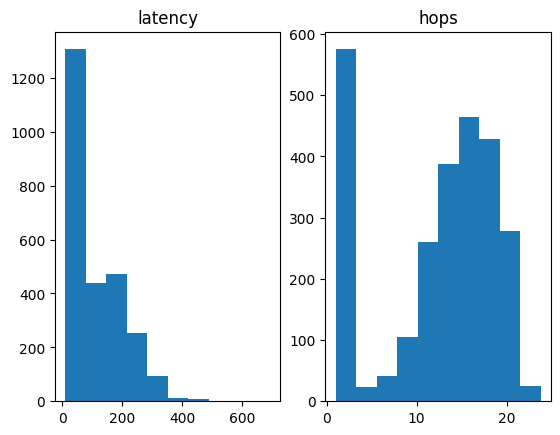

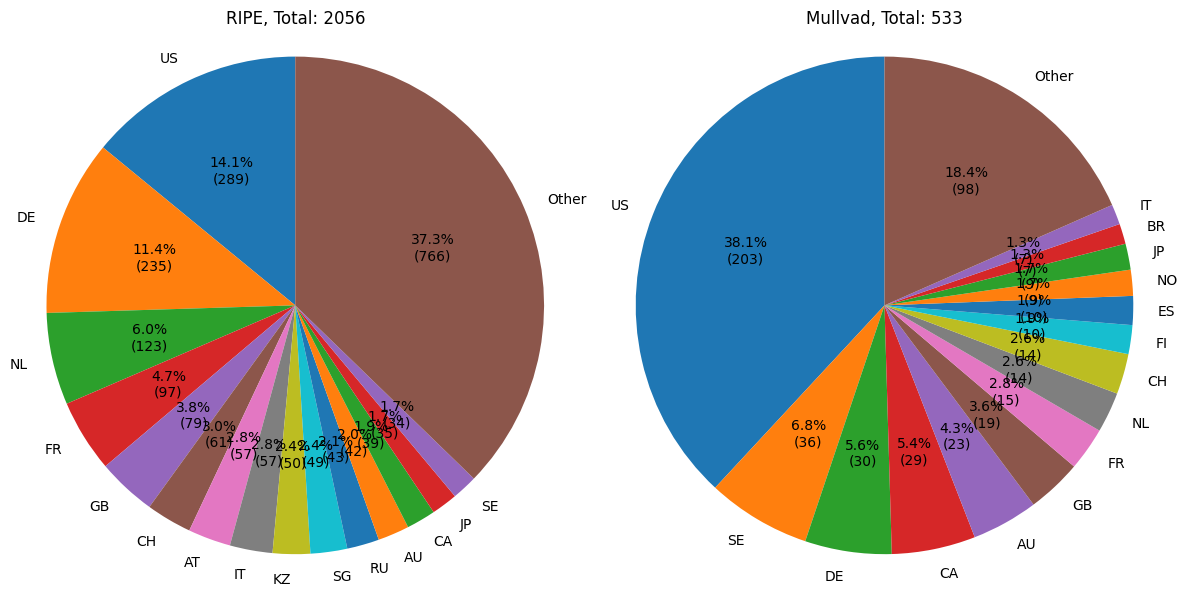

In [2]:
%run preparation.ipynb

# Metrics
As we have to predict the country of location of a given server, and because there are many countries out there, this exercise is classification exercise.  

In [3]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def generate_metrics(results: list[tuple]):
    frame = {
        "Classifiers": [], 
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1-Score": []
    }

    for result in results:
        algorithm, test_data, predictions = result

        accuracy = accuracy_score(test_data, predictions)
        precision, recall, f1, _ = precision_recall_fscore_support(
            test_data, 
            predictions, 
            average='weighted', 
            zero_division=np.nan # type: ignore
        ) 
        frame['Classifiers'].append(algorithm)
        frame['Accuracy'].append(accuracy)
        frame['Precision'].append(precision)
        frame['Recall'].append(recall)
        frame['F1-Score'].append(f1)

    return pd.DataFrame(data=frame)

# Models' selection

Fundamentally, our task is about guessing the country of location of a given server, based on a two basic network measurements. This makes this whole exercise a categorisation exercise. 

First and foremost, we will implement models based on exisiting papers. Two models have been selected from the existing litterature based on the fact they only require a single host executing the measurements, and on their use of any machine-learning or statistical technique to guess the location:
 - A Naive-bayes guesser Erikson et al, who has shown to be more reliable than Constraint-based geolocation for targets less than 1000 miles away and using both round-time trip and topology as features. The population-density feature will be left out, however. 
 - A neural-network guesser by Jiang et al, using round-time trip as only determining feature, limited to a single measurement host, and to a single tier. 

Whilst Constraint-Based Geolocation(CBG) is suspected to remain the gold-standard, it would require a dense array of hosts capable of executing those measurements, defeating the point of a single-host geolocation predicator. Naturally, all other methods, like Erikson's latter Posit, which are based on CGB algorithms, are ruled-out. 
Surprisingly, Erikson's last paper on geolocation asserted that the statistical approach was one of the best methods available and outperformed single CBG implementations.

## Naive bayes

### Transformation
Now let's finish the transformation on the train set. Because our features 'latency' and 'hops' follow a non-gaussian distribution and display numerous outliers, a simple Min-Max normalisation should suffice to make sure both features are on the same scale. A Z-score normalisation would have been inappropriate directly due to the non-gaussian nature of our distribution. 

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler
import pandas as pd
import numpy as np
from sklearn import set_config

set_config(transform_output="pandas")

def sqrt_transform(df):
    result = np.sqrt(df.values)
    return pd.DataFrame(result, index=df.index, columns=["sqrt"])

nb_preprocessing = ColumnTransformer([
    ("sqrt", FunctionTransformer(sqrt_transform), ["latency"]),
    ("untouched", FunctionTransformer(lambda x: x), ["hops"])
], remainder='passthrough')

prepared_train_set = nb_preprocessing.fit_transform(train_set) # type: ignore
prepared_dev_set = nb_preprocessing.fit_transform(dev_set) # type: ignore

feature_columns = ['sqrt__sqrt', 'untouched__hops']
label_column = 'remainder__ground_truth'
x_train = prepared_train_set[feature_columns]   # type: ignore # shape (n_samples, 2)
y_train = prepared_train_set[label_column] # type: ignore

x_test = prepared_dev_set[feature_columns] # type: ignore
y_test = prepared_dev_set[label_column] # type: ignore

prepared_dev_set

,sqrt__sqrt,untouched__hops,remainder__origin,remainder__ground_truth
588,5.590684,14.25,RIPE,DE
1033,7.251534,19.50,RIPE,IT
96,6.501308,15.25,RIPE,AT
1002,8.313588,19.00,RIPE,IT
515,5.753521,15.00,RIPE,DE
...,...,...,...,...
135,7.250190,11.00,RIPE,AT
1594,7.641875,20.25,RIPE,SE
262,8.178463,14.00,RIPE,CH
1082,10.613082,18.25,RIPE,KZ


## Tuning 

In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

parameters = {'var_smoothing': [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 1e-10, 1e-11, 1e-12, 1e-13, 1e-14, 1e-15]}
gs_gnb = GridSearchCV(estimator=gnb, param_grid=parameters, cv=5, verbose=1, scoring='f1') 
gs_gnb.fit(x_train, y_train)

gs_gnb.best_params_

Fitting 5 folds for each of 15 candidates, totalling 75 fits


d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 409, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\m

{'var_smoothing': 0.1}


### Execution
Unfortunately, it seems the good performance of the Naive-bayes classifier cannot seem to be replicated.
It is suspected the missing population density matrix or the lack of many measurement hosts were critical components of the datasets, thus tanking the overall performance of the classifier. Other normalisation transformers were tested (PowerTransformer and QuartileTransformer), but worsened the classifier's performance even more.

In [34]:
gnb = GaussianNB(**gs_gnb.best_params_)
results: list[tuple] = []
gaussian_nb_predictions = gnb.fit(x_train, y_train).predict(x_test)
results.append(("Naive-Bayes", y_test, gaussian_nb_predictions))

generate_metrics(results)

,Classifiers,Accuracy,Precision,Recall,F1-Score
0,Naive-Bayes,0.288889,0.434486,0.288889,0.166581


## Multinomial SVM classifier

Following Geron's first multiclass attempt at a classifier, a one-versus-all classifier was assessed. Normally, SVM applies only to binary classification, but a SVm with one-versus-all strategie handles multiclass classification by training a separate binary SVM classifier for each class against all others combined, predicting the class with the highest confidence score. This also has for major advantage to grant us a way to measure how reliable each guess was. 

### Preparation

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures

numerical_preprocessor = make_pipeline(
    PolynomialFeatures(degree=2),
    MinMaxScaler(),
)

svm_preprocesor = ColumnTransformer([
    ("prepare", numerical_preprocessor, ["latency", "hops"]),
], remainder='passthrough')

prepared_train_set = svm_preprocesor.fit_transform(train_set) # type: ignore
prepared_dev_set = svm_preprocesor.fit_transform(dev_set) # type: ignore


feature_columns = ['prepare__latency', 'prepare__hops']
label_column = 'remainder__ground_truth'
x_train = prepared_train_set[feature_columns]   # type: ignore # shape (n_samples, 2)
y_train = prepared_train_set[label_column] # type: ignore

x_test = prepared_dev_set[feature_columns] # type: ignore
y_test = prepared_dev_set[label_column] # type: ignore

prepared_dev_set

,prepare__1,prepare__latency,prepare__hops,prepare__latency^2,prepare__latency hops,prepare__hops^2,remainder__origin,remainder__ground_truth
588,0.0,0.047699,0.597701,0.004664,0.061269,0.382036,RIPE,DE
1033,0.0,0.099186,0.839080,0.014536,0.151364,0.717976,RIPE,IT
96,0.0,0.074280,0.643678,0.009133,0.092208,0.437967,RIPE,AT
1002,0.0,0.139091,0.816092,0.025643,0.196068,0.681479,RIPE,IT
515,0.0,0.052158,0.632184,0.005320,0.069214,0.423628,RIPE,DE
...,...,...,...,...,...,...,...,...
135,0.0,0.099139,0.448276,0.014525,0.081901,0.226449,RIPE,AT
1594,0.0,0.113220,0.873563,0.018098,0.175776,0.774499,RIPE,SE
262,0.0,0.133711,0.586207,0.023969,0.137542,0.368646,RIPE,CH
1082,0.0,0.244150,0.781609,0.069312,0.311394,0.628510,RIPE,KZ


## Tuning

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

svc = SVC(random_state=42, cache_size=1000)

parameters = {'kernel':['linear', 'poly', 'rbf', 'sigmoid'], 'decision_function_shape': ['ovo', 'ovr'],  'C': [1, 10, 100],}

gs_dtc = GridSearchCV(svc, parameters, cv=5, verbose=True, scoring="f1_weighted", n_jobs=-1)
gs_dtc.fit(x_train, y_train)
# Access the best hyperparameters found by GridSearchCV
gs_dtc.best_params_

Fitting 5 folds for each of 24 candidates, totalling 120 fits


{'C': 100, 'decision_function_shape': 'ovo', 'kernel': 'rbf'}

### Execution

In [9]:
svc = SVC(**gs_dtc.best_params_, random_state=42)
svm_predictions = svc.fit(x_train, y_train).predict(x_test)
results.append(("SVM", y_test, svm_predictions))
generate_metrics(results)

,Classifiers,Accuracy,Precision,Recall,F1-Score
0,Naive-Bayes,0.316667,0.294051,0.316667,0.203124
1,SVM,0.327778,0.294276,0.327778,0.255420


## Decision-tree classifier and nearest neighbour

### Preparation 

In [10]:
def sqrt_transform(df):
    # df is a DataFrame with one column (latency)
    result = np.sqrt(df.values)
    return pd.DataFrame(result, index=df.index, columns=["sqrt"])

nb_preprocessing = ColumnTransformer([
    # Scale original latency and hops
    ("standardise", MinMaxScaler(), ["latency", "hops"]),
], remainder='passthrough')

prepared_train_set = nb_preprocessing.fit_transform(train_set) # type: ignore
prepared_dev_set = nb_preprocessing.fit_transform(dev_set) # type: ignore

feature_columns = ['standardise__latency', 'standardise__hops']
label_column = 'remainder__ground_truth'
x_train = prepared_train_set[feature_columns]   # type: ignore # shape (n_samples, 2)
y_train = prepared_train_set[label_column] # type: ignore

x_test = prepared_dev_set[feature_columns] # type: ignore
y_test = prepared_dev_set[label_column] # type: ignore


### Tuning

In [11]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(random_state=42)

parameters = {'criterion':('gini', 'entropy', 'log_loss'), 'splitter':["best", "random"]}

gs_dtc = GridSearchCV(dtc, parameters, cv=5, verbose=True, scoring="f1")
gs_dtc.fit(x_train, y_train)
# Access the best hyperparameters found by GridSearchCV
gs_dtc.best_params_

Fitting 5 folds for each of 6 candidates, totalling 30 fits


d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 409, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\m

{'criterion': 'gini', 'splitter': 'best'}

In [12]:
from sklearn.neighbors import KNeighborsClassifier

nnc = KNeighborsClassifier()

parameters = {'weights':('uniform', 'distance'), 'algorithm':["ball_tree", "kd_tree", "brute"], 'n_neighbors': range(1, 5)}

gs_nnc = GridSearchCV(nnc, parameters, cv=5, verbose=True, scoring="f1")
gs_nnc.fit(x_train, y_train)
# Access the best hyperparameters found by GridSearchCV
best_params = gs_nnc.best_params_
best_params

Fitting 5 folds for each of 24 candidates, totalling 120 fits


d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 409, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\m

{'algorithm': 'ball_tree', 'n_neighbors': 1, 'weights': 'uniform'}

## Execution

In [13]:
dtc = DecisionTreeClassifier(**gs_dtc.best_params_, random_state=42)
nnc = KNeighborsClassifier(**gs_nnc.best_params_)

dtc_predictions = dtc.fit(x_train, y_train).predict(x_test)
#best_model
results.append(("Decision Tree", y_test, dtc_predictions))
nkc_predictions = nnc.fit(x_train, y_train).predict(x_test)
results.append(("Nearest Neighbour", y_test, nkc_predictions))
generate_metrics(results)

,Classifiers,Accuracy,Precision,Recall,F1-Score
0,Naive-Bayes,0.316667,0.294051,0.316667,0.203124
1,SVM,0.327778,0.294276,0.327778,0.255420
2,Decision Tree,0.255556,0.265903,0.255556,0.256327
3,Nearest Neighbour,0.286111,0.307069,0.286111,0.288693


# MLP

### Tuning

In [14]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(random_state=42)
parameters = {'solver':['lbfgs', 'sgd', 'adam'], 
              'activation':['relu', 'identity', 'logistic', 'tanh'], 
              'hidden_layer_sizes':[5], 
              'max_iter': [2000]
              }

gs_mlp = GridSearchCV(mlp, parameters, cv=5, verbose=True, scoring="f1", n_jobs=-1)
gs_mlp.fit(x_train, y_train)
# Access the best hyperparameters found by GridSearchCV
gs_mlp.best_params_

Fitting 5 folds for each of 12 candidates, totalling 60 fits


d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


{'activation': 'relu',
 'hidden_layer_sizes': 5,
 'max_iter': 2000,
 'solver': 'lbfgs'}

### Execution

In [15]:
gs_mlp.best_params_['max_iter'] = 200_000
mlp = MLPClassifier(**gs_mlp.best_params_,  random_state=42).fit(x_train, y_train)
mlp_predictions = mlp.predict(x_test)
results.append(("MLP", y_test, mlp_predictions))
generate_metrics(results)

,Classifiers,Accuracy,Precision,Recall,F1-Score
0,Naive-Bayes,0.316667,0.294051,0.316667,0.203124
1,SVM,0.327778,0.294276,0.327778,0.255420
2,Decision Tree,0.255556,0.265903,0.255556,0.256327
3,Nearest Neighbour,0.286111,0.307069,0.286111,0.288693
4,MLP,0.330556,0.275786,0.330556,0.200143


In [16]:
from sklearn.ensemble import GradientBoostingClassifier
gdc = GradientBoostingClassifier(random_state=42)
parameters = {'loss':['log_loss', 'deviance', 'exponential'], 
              'criterion': ['friedman_mse', 'squared_error'], 
              }

gd_gdc = GridSearchCV(gdc, parameters, cv=5, verbose=True, scoring="f1", n_jobs=-1)
gd_gdc.fit(x_train, y_train)
# Access the best hyperparameters found by GridSearchCV
gd_gdc.best_params_

Fitting 5 folds for each of 6 candidates, totalling 30 fits


d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
20 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
9 fits failed with the following error:
Traceback (most recent call last):
  File "d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\base.

{'criterion': 'friedman_mse', 'loss': 'log_loss'}

## Ensemble learning 

### Tuning

### Execution 

In [17]:
from sklearn.metrics import classification_report 
from sklearn.ensemble import VotingClassifier 

ensemble = VotingClassifier(estimators=[
    ("Naive-Bayes", gnb),
    #("SVM", svc), 
    ("Decision Tree", dtc), 
    ("Nearest Neighbour", nnc), 
    ("Multilayer perceptron", mlp),
    #("Gradient Boost", gdc)
], voting="hard").fit(x_train, y_train)

ensemble_predictions = ensemble.predict(x_test)
report = classification_report(y_test, ensemble_predictions)
#print(report)

results.append(("Ensemble", y_test, ensemble_predictions))
generate_metrics(results)

d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

,Classifiers,Accuracy,Precision,Recall,F1-Score
0,Naive-Bayes,0.316667,0.294051,0.316667,0.203124
1,SVM,0.327778,0.294276,0.327778,0.255420
2,Decision Tree,0.255556,0.265903,0.255556,0.256327
3,Nearest Neighbour,0.286111,0.307069,0.286111,0.288693
4,MLP,0.330556,0.275786,0.330556,0.200143
5,Ensemble,0.344444,0.429235,0.344444,0.280116


# Performance summary 

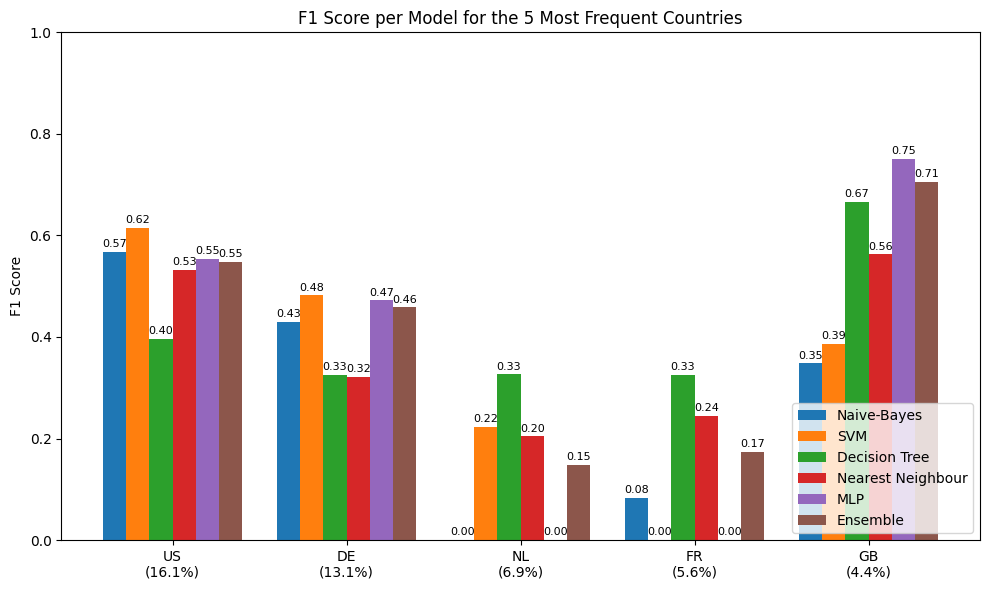

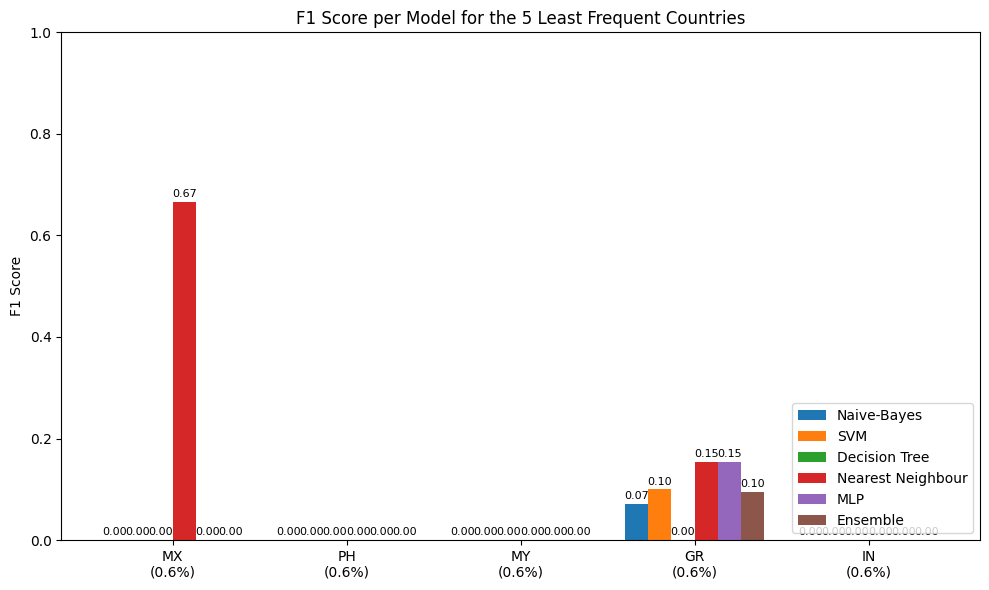

In [18]:
from shared import create_bar_chart_multi_models

create_bar_chart_multi_models(y_test, results)
create_bar_chart_multi_models(y_test, results, True)

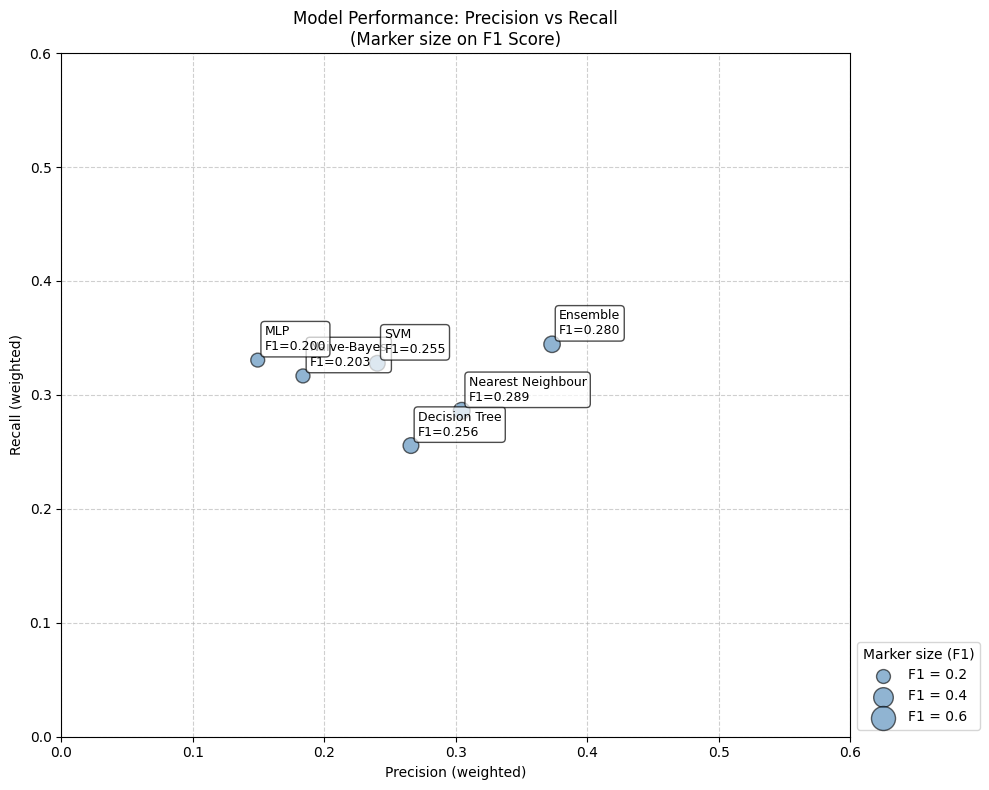

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

model_names = []
precisions = []
recalls = []
f1_scores = []

for name, y_true, y_pred in results:
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    model_names.append(name)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

plt.figure(figsize=(10, 8))

sizes = [f1 * 500 for f1 in f1_scores]  # adjust multiplier for visibility

scatter = plt.scatter(precisions, recalls, s=sizes, alpha=0.6, c='steelblue', edgecolors='black')

for i, name in enumerate(model_names):
    plt.annotate(
        f"{name}\nF1={f1_scores[i]:.3f}",
        (precisions[i], recalls[i]),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9,
        ha='left',
        va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7)
    )

plt.xlabel('Precision (weighted)')
plt.ylabel('Recall (weighted)')
plt.title('Model Performance: Precision vs Recall\n(Marker size on F1 Score)')
plt.grid(True, linestyle='--', alpha=0.6)

# Set axes limits from 0 to 0.6 (since values are around 0.4)
plt.xlim(0, 0.6)
plt.ylim(0, 0.6)

sizes_legend = [0.2, 0.4, 0.6]
for f1_val in sizes_legend:
    plt.scatter([], [], s=f1_val*500, c='steelblue', alpha=0.6, edgecolors='black',
                label=f'F1 = {f1_val:.1f}')
plt.legend(title='Marker size (F1)', loc='lower left', bbox_to_anchor=(1, 0))

plt.tight_layout()
plt.show()

# Model export

In [20]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import VotingClassifier

preprocessor = MinMaxScaler()

gnb_final = GaussianNB(var_smoothing=0.01)

svc_final = SVC(C=100, decision_function_shape='ovo', kernel='rbf', random_state=42, probability=False)
dtc_final = DecisionTreeClassifier(criterion='gini', splitter='best', random_state=42)
nnc_final = KNeighborsClassifier(algorithm='ball_tree', n_neighbors=1, weights='uniform')
mlp_final = MLPClassifier(activation='relu', hidden_layer_sizes=5, max_iter=2000, solver='lbfgs', random_state=42)

ensemble_final = VotingClassifier(
    estimators=[
        ('nb', gnb_final),
        ('svm', svc_final),
        ('dt', dtc_final),
        ('knn', nnc_final),
        ('mlp', mlp_final)
    ],
    voting='hard'
)

full_pipeline = Pipeline([
    ('scaler', preprocessor),
    ('classifier', ensemble_final)
])

X_train_raw = train_set[['latency', 'hops']].copy() # type: ignore
y_train_raw = train_set['ground_truth'].copy() # type: ignore

full_pipeline.fit(X_train_raw, y_train_raw)

joblib.dump(full_pipeline, 'geolocation_pipeline.pkl')
print("Pipeline saved as 'geolocation_pipeline.pkl'")

Pipeline saved as 'geolocation_pipeline.pkl'


d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


# Test set

In [41]:
from pathlib import Path

from pandas import DataFrame

from shared import create_best_performing_bar_chart, create_frequency_bar_chart

dataset = pd.read_csv(
    Path("clean_dataset.csv"), 
    skip_blank_lines=True, 
    header=0)

dataset["latency"] = pd.to_numeric(dataset.latency, errors='coerce')
dataset["hops"] = pd.to_numeric(dataset.hops, errors='coerce')

grouped = dataset.groupby(dataset.origin)
test_set = grouped.get_group("Mullvad")

ensemble = joblib.load('geolocation_pipeline.pkl')
prediction = ensemble.predict(test_set[['latency', 'hops']])

y_true = test_set["ground_truth"]

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, prediction, average='weighted', zero_division=0
)
accuracy = accuracy_score(y_true, prediction)

DataFrame([[accuracy, precision, recall, f1]], columns=["Accuracy", "Precision", "Recall", "F1"])

,Accuracy,Precision,Recall,F1
0,0.248588,0.339327,0.248588,0.26402


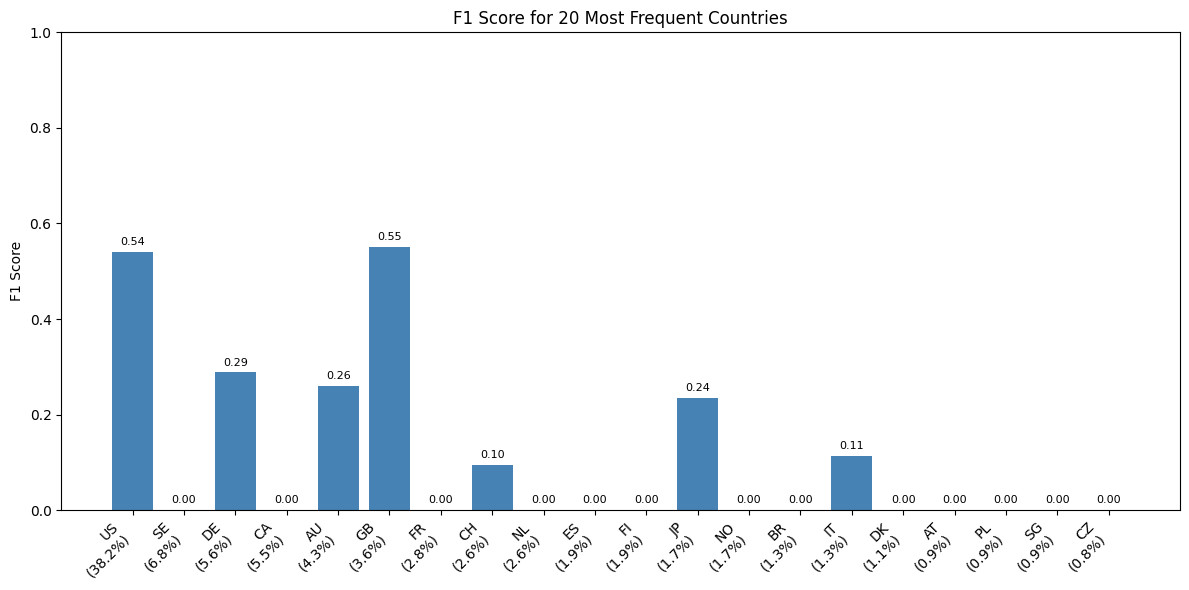

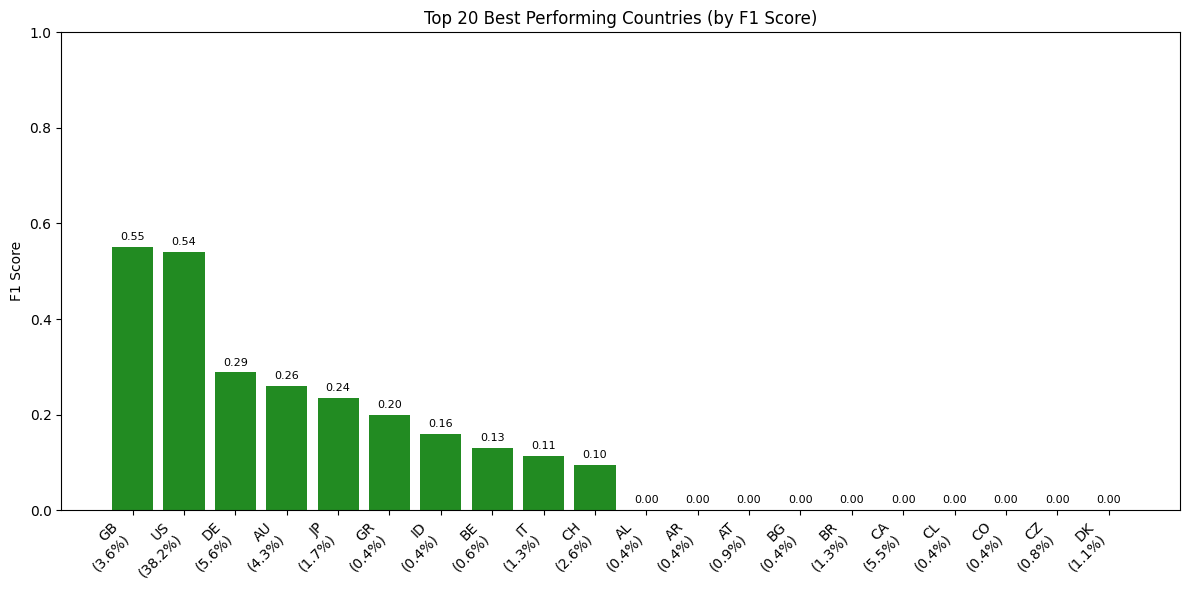

In [42]:
create_frequency_bar_chart(test_set, prediction)
create_best_performing_bar_chart(test_set, prediction)